# **Etapa 1: Extração e tratamento de dados**

In [1]:
import pandas as pd          # Biblioteca para trabalhar com tabelas (DataFrames)
import requests              # Biblioteca para acessar páginas da internet
import shutil
import os
import yfinance as yf   # Biblioteca para baixar dados financeiros
import matplotlib.pyplot as plt
import numpy as np
from pypfopt import EfficientFrontier, risk_models, expected_returns
import gymnasium as gym
from gymnasium import spaces    
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from joblib import Parallel, delayed
import torch
from io import StringIO

In [2]:
# Endereço da página da Wikipedia que contém a lista do S&P 100
url = "https://en.wikipedia.org/wiki/S%26P_100"

# Cabeçalho que "imita" um navegador comum
# Isso é necessário porque a Wikipedia bloqueia acessos que parecem ser de robôs
headers = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

# Faz o pedido para acessar a página da Wikipedia
response = requests.get(url, headers=headers)

# Se a página não puder ser acessada (erro 403, 404, etc),
# o programa para aqui e mostra o erro
response.raise_for_status()

# Lê todas as tabelas existentes no HTML da página
# O resultado é uma lista de tabelas (DataFrames)
tables = pd.read_html(StringIO(response.text))


In [3]:
# Inicializamos a variável como None (vazia)
# Ela vai guardar a tabela correta do S&P 100
sp100_table = None

# Percorremos todas as tabelas encontradas na página
for table in tables:
    # Verificamos se essa tabela tem uma coluna chamada "Symbol"
    # Essa coluna contém os códigos das ações (tickers)
    if "Symbol" in table.columns:
        sp100_table = table
        break  # Paramos o loop assim que encontramos a tabela correta

# Se nenhuma tabela com a coluna "Symbol" foi encontrada,
# levantamos um erro para avisar que algo deu errado
if sp100_table is None:
    raise ValueError("Tabela do S&P 100 não encontrada")

# Extraímos apenas a coluna "Symbol" da tabela
# e transformamos em uma lista Python
tickers = sp100_table["Symbol"].tolist()

# Ajuste necessário para o Yahoo Finance:
# alguns tickers usam ponto (.) na Wikipedia,
# mas no Yahoo Finance usam hífen (-)
# Exemplo: BRK.B → BRK-B
tickers = [t.replace(".", "-") for t in tickers]

# Mostra quantos tickers foram extraídos
print(f"{len(tickers)} tickers extraídos")

# Mostra os 10 primeiros tickers como conferência
print(tickers[:10])


101 tickers extraídos
['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMD', 'AMGN', 'AMT', 'AMZN']


In [4]:
# Definimos o período desejado
data_inicio = "2015-01-01"
data_fim = "2025-12-31"

# Faz o download dos dados de todas as ações de uma vez
# interval="1d" significa dados diários
# group_by="ticker" organiza os dados por ação
dados = yf.download(
    tickers=tickers,
    start=data_inicio,
    end=data_fim,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,   # Não ajusta automaticamente (vamos usar Adj Close)
    threads=True         # Baixa várias ações em paralelo (mais rápido)
)

# Exibe uma mensagem de confirmação
print("Download dos dados concluído!")


[*********************100%***********************]  101 of 101 completed

Download dos dados concluído!


In [5]:
# Converte o DataFrame com colunas hierárquicas
# para um formato "longo" (organizado)
dados_long = (
    dados
    .stack(level=0)            # transforma tickers em linhas
    .reset_index()
    .rename(columns={"level_1": "Ticker"})
)

# Reorganiza a ordem das colunas (opcional)
dados_long = dados_long[
    ["Date", "Ticker", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
]

# Visualização rápida
print(dados_long.head())

# Salva os dados no formato CSV
dados_long.to_csv(
    "sp100_ohlcv_2015_2025.csv",
    index=False  # não salva o índice (o Date já é coluna)
)

print("Dados completos salvos em CSV!")

Price       Date Ticker       Open       High        Low      Close  \
0     2015-01-02  GOOGL  26.629999  26.790001  26.393999  26.477501   
1     2015-01-02   AVGO  10.093000  10.221000   9.913000  10.009000   
2     2015-01-02    TGT  76.110001  76.639999  74.550003  75.330002   
3     2015-01-02    NKE  48.275002  48.474998  47.055000  47.514999   
4     2015-01-02     MO  49.299999  49.639999  48.580002  48.970001   

Price  Adj Close      Volume  
0      26.278946  26480000.0  
1       7.560340  13500000.0  
2      54.419563   3710300.0  
3      41.381516   4985800.0  
4      24.103952   6078100.0  
Dados completos salvos em CSV!


In [6]:
# Criar uma pasta para não bagunçar o computador
os.makedirs("dados_acoes", exist_ok=True)

# Pegar a lista de todos os tickers que estão no tabelão
lista_tickers = dados_long['Ticker'].unique()

for acao in lista_tickers:
    tabela_individual = dados_long[dados_long['Ticker'] == acao]
    
    # Cria o arquivo com o nome da ação (ex: AAPL.csv)
    tabela_individual.to_csv(f"dados_acoes/{acao}.csv", index=False)

print(f"{len(lista_tickers)} arquivos foram separados na pasta 'dados_acoes'.")

# Cria um arquivo .zip com tudo o que tem na pasta
shutil.make_archive('dados_acoes', 'zip', 'dados_acoes')

101 arquivos foram separados na pasta 'dados_acoes'.


'c:\\Users\\julia\\OneDrive\\Documentos\\FinQuant\\Projeto finquant\\Agora vai\\Grupo-1--FinQuant\\dados_acoes.zip'

### Gerando matriz

In [7]:
pasta_arquivos = "dados_acoes"

precos_dict = {}
contagem_novas = 0
empresas_novas = []

# Data de Início do Projeto
data_inicio_projeto = pd.Timestamp("2020-01-01")

print("--- Carregando Dados ---")

# Varre todos os arquivos
arquivos = [f for f in os.listdir(pasta_arquivos) if f.endswith('.csv')]

for arquivo in arquivos:
    ticker = arquivo.replace(".csv", "")
    
    # Lê o arquivo
    caminho_completo = os.path.join(pasta_arquivos, arquivo)
    df_temp = pd.read_csv(caminho_completo)
    
    # Arruma data e índice
    df_temp['Date'] = pd.to_datetime(df_temp['Date'])
    df_temp = df_temp.set_index('Date')
    
    # Apenas guardamos o preço. O Pandas vai preencher o resto com NaN (Vazio).
    
    precos_dict[ticker] = df_temp['Adj Close']

# Consolida a Matriz
df_matriz = pd.DataFrame(precos_dict)

# Restringe aos últimos 5 anos do projeto
df_matriz = df_matriz[df_matriz.index >= data_inicio_projeto]

    
# Conta novas empresas
datas_inicio = df_matriz.apply(lambda col: col.first_valid_index())
# A data mais comum (moda) é considerada o "início do projeto"
data_padrao = datas_inicio.mode()[0]
print(f"Data padrão detectada (maioria das empresas): {data_padrao.strftime('%Y-%m-%d')}")

# Quem começou depois dessa data é "nova"
empresas_novas = datas_inicio[datas_inicio > data_padrao]
print(f"\nRelatório de empresas novas ({len(empresas_novas)} encontradas):")
# Ordena por data de estreia
empresas_novas_sorted = empresas_novas.sort_values()
for ticker, data in empresas_novas_sorted.items():
    print(f"   -> {ticker} (Estreou em: {data.strftime('%Y-%m-%d')})")

print("\n--- Caçando Gêmeas (Correlação > 99%) ---")
# Cálculo da Correlação para achar duplicatas
# Usamos apenas dados recentes para garantir que todas tenham preços na comparação
df_check = df_matriz.dropna() 
correlacao = df_check.corr().abs()

# Pega o triângulo de cima da matriz (pra não conferir A com B e B com A)
upper = correlacao.where(np.triu(np.ones(correlacao.shape), k=1).astype(bool))

to_drop = [] 
LIMITE_CORRELACAO = 0.99
# Acha colunas com correlação > 0.99
for coluna in upper.columns:
    # Se essa coluna tiver correlação alta com ALGUÉM
    if any(upper[coluna] > LIMITE_CORRELACAO):
        # Descobre quem é a "irmã" dela
        irma = upper[coluna][upper[coluna] > LIMITE_CORRELACAO].index[0]
        score = upper[coluna][upper[coluna] > LIMITE_CORRELACAO].values[0]

        print(f"DUPLICATA DETECTADA:")
        print(f"Entre: {irma} e {coluna} (Correlação: {score:.4f})")
        print(f"Decisão: Removendo '{coluna}' e mantendo '{irma}'.")
        to_drop.append(coluna)

# Limpeza
df_final = df_matriz.drop(columns=to_drop)

# Salvar
arquivo_saida = "matriz_final_v3_survivorship.csv"
df_final.to_csv(arquivo_saida)

print("-" * 40)
print(f"PROCESSO AUTOMÁTICO CONCLUÍDO!")
print(f"Ativos Removidos: {len(to_drop)}")
print(f"Ativos Restantes: {df_final.shape[1]}")
print(f"Salvo em: '{arquivo_saida}'")

--- Carregando Dados ---
Data padrão detectada (maioria das empresas): 2020-01-02

Relatório de empresas novas (1 encontradas):
   -> PLTR (Estreou em: 2020-09-30)

--- Caçando Gêmeas (Correlação > 99%) ---
DUPLICATA DETECTADA:
Entre: GOOG e GOOGL (Correlação: 0.9999)
Decisão: Removendo 'GOOGL' e mantendo 'GOOG'.
----------------------------------------
PROCESSO AUTOMÁTICO CONCLUÍDO!
Ativos Removidos: 1
Ativos Restantes: 100
Salvo em: 'matriz_final_v3_survivorship.csv'


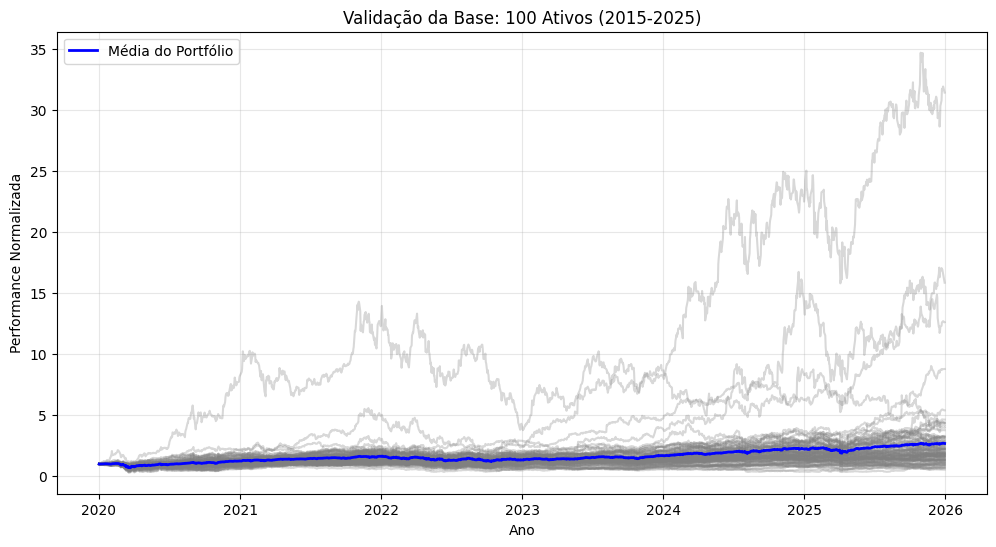

O outlier é: NVDA
Ela multiplicou o capital por 31.41 vezes.


In [8]:
# Validação visual dos dados
df = pd.read_csv("matriz_final_v3_survivorship.csv", index_col="Date", parse_dates=True)

# Normaliza para tudo começar em 1 (para o gráfico ficar comparável)
# É possível ver se tem algum dado bizarro ou algum buraco
df_norm = df / df.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(df_norm, alpha=0.3, color='gray') # Todas as ações em cinza
plt.plot(df_norm.mean(axis=1), color='blue', linewidth=2, label='Média do Portfólio') # A média em destaque
plt.title(f"Validação da Base: {len(df.columns)} Ativos (2015-2025)")
plt.xlabel("Ano")
plt.ylabel("Performance Normalizada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("validacao_dados.png") # Salva pra você mandar
plt.show()

# Pega o valor acumulado no último dia
retorno_total = df_norm.iloc[-1]

# Descobre quem é o máximo
nome_max = retorno_total.idxmax()
quanto_cresceu = retorno_total.max()

print(f"O outlier é: {nome_max}")
print(f"Ela multiplicou o capital por {quanto_cresceu:.2f} vezes.")

In [9]:
df_precos = df_final.copy()

df_retornos = df_precos.pct_change().dropna()

janelas = {
    "curta": 5,
    "media": 21,
    "longa": 63
}

retornos_medios = {}

for nome, janela in janelas.items():
    retornos_medios[f"retorno_{nome}"] = (
        df_retornos.rolling(janela).mean()
    )

volatilidades = {}

for nome, janela in janelas.items():
    volatilidades[f"vol_{nome}"] = (
        df_retornos.rolling(janela).std()
    )


# Médias Móveis
mm_curta = df_precos.rolling(21).mean()
mm_longa = df_precos.rolling(63).mean()

mm_diff = mm_curta - mm_longa

momentum = {
    "mom_21": df_precos.pct_change(21),
    "mom_63": df_precos.pct_change(63)
}

def rolling_drawdown(precos, janela):
    max_rolling = precos.rolling(janela).max()
    drawdown = precos / max_rolling - 1
    return drawdown

drawdown_63 = rolling_drawdown(df_precos, 63)

sharpe_local = {}

for nome in janelas.keys():
    sharpe_local[f"sharpe_{nome}"] = (
        retornos_medios[f"retorno_{nome}"] /
        volatilidades[f"vol_{nome}"]
    )

features = []

features.extend(retornos_medios.values())
features.extend(volatilidades.values())
features.extend(momentum.values())
features.extend(sharpe_local.values())
features.append(mm_diff)
features.append(drawdown_63)

df_features = pd.concat(features, axis=1)
df_features = df_features.dropna()

df_features_norm = (df_features - df_features.mean()) / df_features.std()

df_features_norm.to_csv("features_rl_sp100.csv")

# Alinhar os retornos brutos (para calcular o lucro real) com as features
df_retornos = df_retornos.loc[df_features_norm.index]

# Separar treino e teste (ex: 80% treino, 20% teste - sem embaralhar pois é série temporal)
split_idx = int(len(df_features_norm) * 0.8)

train_features = df_features_norm.iloc[:split_idx]
train_returns = df_retornos.iloc[:split_idx]

test_features = df_features_norm.iloc[split_idx:]
test_returns = df_retornos.iloc[split_idx:]

print(f"Treino: {train_features.shape}, Teste: {test_features.shape}")

C:\Users\julia\AppData\Local\Temp\ipykernel_2604\2317608737.py:61: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_features = pd.concat(features, axis=1)


Treino: (1004, 1300), Teste: (252, 1300)


# **Etapa 2: Benchmarks**

Calcularemos a estratégia Naive e estratégia de Markowitz para entender os valores a serem batidos. 

### Naive

In [10]:
df = pd.read_csv(
    "matriz_final_v3_survivorship.csv",
    sep=",",
    index_col=0,     
    parse_dates=True
)

split_idx = int(len(df) * 0.8)
df = df.iloc[split_idx:]

# ajustando as colunas
numeric_cols = df.columns[df.dtypes != "object"]
df_numeric = df[numeric_cols]

In [11]:
# calcular retornos
returns = df_numeric.pct_change().dropna()
returns.describe()

,AAPL,ABBV,ABT,ACN,ADBE,AIG,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,...,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,0.000744,0.000895,0.000370,-0.000865,-0.000964,0.000564,0.001707,0.000354,-0.000566,0.000952,...,0.000303,-0.001277,-0.000008,-0.000569,0.000621,0.000811,0.000059,0.001566,0.001218,0.000256
std,0.019126,0.017653,0.013454,0.017589,0.020401,0.014787,0.036425,0.017284,0.016038,0.021334,...,0.024279,0.028612,0.014378,0.019771,0.017134,0.013723,0.013400,0.019129,0.015133,0.014115
min,-0.092456,-0.125664,-0.085244,-0.072611,-0.138532,-0.084107,-0.106165,-0.071378,-0.076596,-0.089791,...,-0.096037,-0.223797,-0.060765,-0.141127,-0.098117,-0.077374,-0.065821,-0.091199,-0.065288,-0.071956
25%,-0.006443,-0.006643,-0.006083,-0.009533,-0.008276,-0.006705,-0.017136,-0.008195,-0.007646,-0.010250,...,-0.011763,-0.011080,-0.007326,-0.009087,-0.006624,-0.005118,-0.006710,-0.006819,-0.006426,-0.006741
50%,0.001140,0.000176,0.000700,-0.000430,0.000085,0.000580,0.000769,0.001027,0.000696,0.001034,...,0.000994,-0.000099,0.000173,-0.000260,0.000818,0.001197,-0.000242,0.001685,0.001436,0.000553
75%,0.007535,0.009821,0.007489,0.008483,0.009043,0.008216,0.017643,0.009124,0.008233,0.012956,...,0.013184,0.012119,0.007037,0.009541,0.008900,0.008130,0.007515,0.011266,0.008999,0.008991
max,0.153289,0.063605,0.046188,0.070625,0.072471,0.066306,0.238205,0.078059,0.061198,0.119770,...,0.116951,0.119783,0.073270,0.084204,0.079670,0.078373,0.041375,0.131107,0.095488,0.049916


In [12]:
# estratégia 1/N

n_assets = returns.shape[1]
weights_1N = np.ones(n_assets) / n_assets

portfolio_returns_1N = returns @ weights_1N
cumulative_returns_1N = (1 + portfolio_returns_1N).cumprod()

# métricas de performance

risk_free_rate = 0.0

annual_return = portfolio_returns_1N.mean() * 252 #retorno anualizado
volatility = portfolio_returns_1N.std() * np.sqrt(252) #volatilidade anualizada
sharpe_ratio = (annual_return - risk_free_rate) / volatility # sharpe ratio

# máximo drawdown
cum_max = cumulative_returns_1N.cummax()
drawdown = cumulative_returns_1N / cum_max - 1
max_drawdown = drawdown.min()

print("Estratégia 1/N")
print(f"Retorno anualizado: {annual_return:.2%}")
print(f"Volatilidade anualizada: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Máximo Drawdown: {max_drawdown:.2%}")

Estratégia 1/N
Retorno anualizado: 15.89%
Volatilidade anualizada: 15.84%
Sharpe Ratio: 1.00
Máximo Drawdown: -15.56%


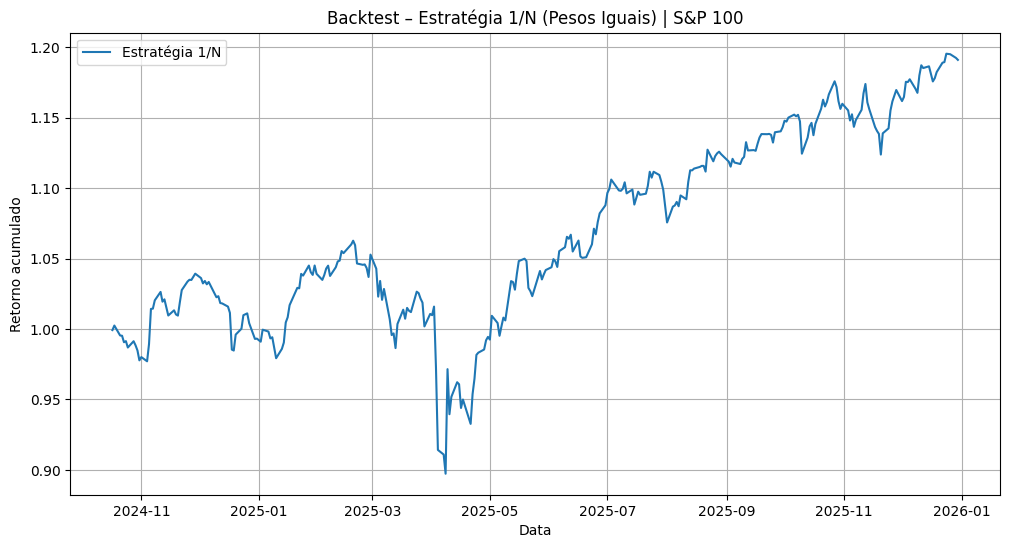

In [13]:
# gráfico
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_1N, label="Estratégia 1/N")
plt.title("Backtest – Estratégia 1/N (Pesos Iguais) | S&P 100")
plt.xlabel("Data")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.grid(True)
plt.show()

### Markowitz

In [14]:
#Baixando a matriz de dados
df_precos = pd.read_csv("matriz_final_v3_survivorship.csv", index_col="Date", parse_dates=True)

#Definindo 20% dos dados para teste
split_idx = int(len(df_precos) * 0.8)
df_teste = df_precos.iloc[split_idx:]

#Configurando a janela móvel para atribuir pesos para cada dia
janela = 63
lista_pesos = []

#Loop para calcular os pesos de cada dia da janela móvel
for i in range(len(df_teste)):
    #Localizando o tempo
    idx_fim = split_idx + i
    #Pegando o histórico imediatamente anterior
    historico = df_precos.iloc[idx_fim - janela : idx_fim]

    try:
        #Retornos médios e Matriz de covariância
        mu = expected_returns.mean_historical_return(historico)
        S = risk_models.sample_cov(historico)
        
        #Otimizando para Mínima Volatilidade (Markowitz de baixo risco)
        ef = EfficientFrontier(mu, S)
        pesos_brutos = ef.min_volatility() 
        
        #Limpando valores insignificantes nos pesos
        pesos_limpos = ef.clean_weights()
        lista_pesos.append(pesos_limpos)
        
    except Exception as e:
        #Caso a matemática falhe em algum dia, repetimos o peso anterior
        print(f"Erro no dia {df_teste.index[i]}: {e}")
        lista_pesos.append(lista_pesos[-1] if lista_pesos else {})


#Salvando o resultado
df_markowitz = pd.DataFrame(lista_pesos, index=df_teste.index)
df_markowitz.to_csv("pesos_markowitz_final.csv")

c:\Users\julia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Users\julia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Users\julia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Users\julia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Users\julia\AppData\Local\Programs\Python\Python313\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalue

In [15]:

#Carregando os preços e os pesos de markowitz
df_precos = pd.read_csv("matriz_final_v3_survivorship.csv", index_col="Date", parse_dates=True)
df_pesos = pd.read_csv("pesos_markowitz_final.csv", index_col="Date", parse_dates=True)

df_retornos = df_precos.pct_change().dropna()
retornos_teste = df_retornos.loc[df_pesos.index]

#Calculando performance diária
retorno_portfólio = (df_pesos * retornos_teste).sum(axis=1)
curva_patrimonio = (1 + retorno_portfólio).cumprod()


risk_free_rate = 0.0422

#Retorno Anualizado
annual_return_mk = retorno_portfólio.mean() * 252

#Volatilidade Anualizada
volatility_mk = retorno_portfólio.std() * np.sqrt(252) 

#Sharpe Ratio
sharpe_ratio_mk = (annual_return_mk - risk_free_rate) / volatility_mk 

#Máximo Drawdown
cum_max_mk = curva_patrimonio.cummax()
drawdown_mk = curva_patrimonio / cum_max_mk - 1
max_drawdown_mk = drawdown_mk.min()


print(f"Retorno anualizado: {annual_return_mk:.2%}")
print(f"Volatilidade anualizada: {volatility_mk:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio_mk:.2f}")
print(f"Máximo Drawdown: {max_drawdown_mk:.2%}")

Retorno anualizado: 0.76%
Volatilidade anualizada: 12.42%
Sharpe Ratio: -0.28
Máximo Drawdown: -10.58%


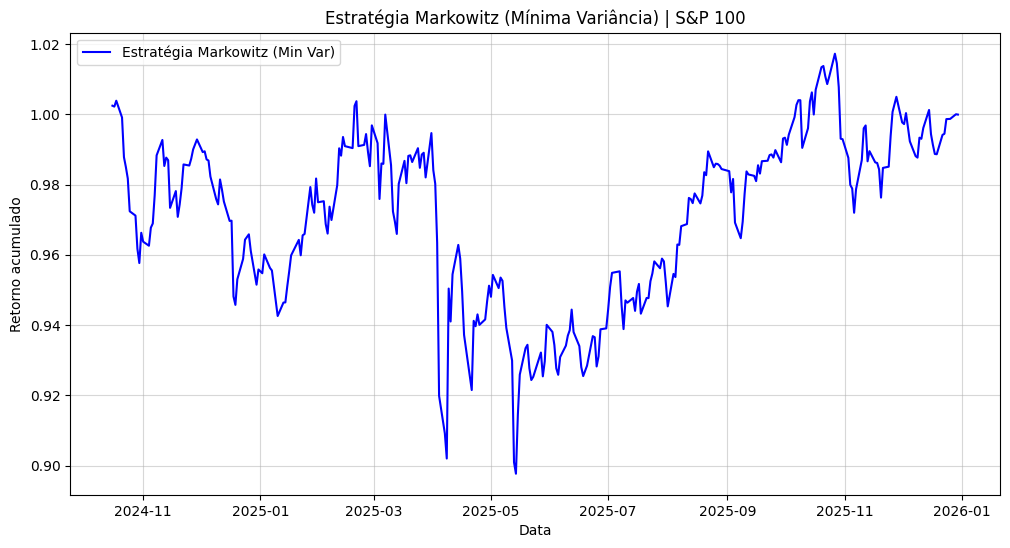

Retorno Final: 1.00


In [16]:

plt.figure(figsize=(12, 6))
plt.plot(curva_patrimonio, label='Estratégia Markowitz (Min Var)', color='blue', linewidth=1.5)

plt.title('Estratégia Markowitz (Mínima Variância) | S&P 100', fontsize=12)
plt.xlabel('Data')
plt.ylabel('Retorno acumulado')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)

plt.savefig("grafico_markowitz.png")
plt.show()

print(f"Retorno Final: {curva_patrimonio.iloc[-1]:.2f}")

# **Etapa 3: Treinamento do modelo**

In [17]:
df_features_norm = pd.read_csv("features_rl_sp100.csv", index_col=0, parse_dates=True)

df_precos = pd.read_csv("matriz_final_v3_survivorship.csv", index_col=0, parse_dates=True)
df_retornos = df_precos.pct_change().dropna()

indices_comuns = df_features_norm.index.intersection(df_retornos.index)

df_features_norm = df_features_norm.loc[indices_comuns]
df_retornos = df_retornos.loc[indices_comuns]

split_idx = int(len(df_features_norm) * 0.8)

train_features = df_features_norm.iloc[:split_idx]
train_returns = df_retornos.iloc[:split_idx]

test_features = df_features_norm.iloc[split_idx:]
test_returns = df_retornos.iloc[split_idx:]

print(f"Pronto! Dados carregados.")
print(f"Treino: {train_features.shape}")

Pronto! Dados carregados.
Treino: (1004, 1300)


In [18]:

class PortfolioEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, features, returns, lambda_risk=0.5, turnover_cost=0.001):
        super(PortfolioEnv, self).__init__()

        self.features = features.values # Matriz de estados
        self.returns = returns.values # Matriz de retornos reais dos ativos
        self.asset_names = returns.columns

        self.n_assets = returns.shape[1]
        self.n_features = features.shape[1]
        self.current_step = 0

        # Hiperparâmetros da Recompensa 
        self.lambda_risk = lambda_risk      # Penalidade por volatilidade
        self.turnover_cost = turnover_cost  # Custo de transação/mudança

        # Espaço de Ação: vetor contínuo de pesos (0 a 1) para cada ativo
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,), dtype=np.float32)
        
        # Espaço de Observação
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_features,), dtype=np.float32)
        
        # Estado inicial dos pesos (começa 100% em caixa ou distribuído igualmente)
        self.last_weights = np.ones(self.n_assets) / self.n_assets

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.last_weights = np.ones(self.n_assets) / self.n_assets
        
        # Retorna a primeira observação e info vazia
        return self.features[self.current_step], {}

    def step(self, action):
        # Normalizar ação para garantir soma = 1 (Alocação de Portfólio) 
        weights = np.exp(action) / np.sum(np.exp(action))
        
        # Pegar o retorno real do dia atual (o que aconteceu no mercado)
        daily_returns = self.returns[self.current_step]
        
        # Calcular retorno do portfólio: soma(pesos * retorno do ativo)
        portfolio_return = np.sum(weights * daily_returns)
        
        # Calcular custo de turnover (penalidade por mudar muito os pesos)
        turnover = np.sum(np.abs(weights - self.last_weights))
        
        # Calcular risco (volatilidade instantânea aproximada pelo retorno quadrático ou janela)
        # Simplificação para recompensa instantânea: Risco ~ (Retorno do portfólio)^2 ou volatilidade recente
        portfolio_risk = portfolio_return ** 2 # Proxy simples de variância local
        
        # Função de recompensa 
        # Reward = Retorno - (lambda * Risco) - (custo * turnover)
        reward = portfolio_return - (self.lambda_risk * portfolio_risk) - (self.turnover_cost * turnover)
        
        # Atualizar estado
        self.last_weights = weights
        self.current_step += 1
        
        # Verificar se acabou os dados
        terminated = self.current_step >= len(self.features) - 1
        truncated = False
        
        # Próximo estado
        next_observation = self.features[self.current_step]
        
        info = {
            'portfolio_return': portfolio_return,
            'turnover': turnover,
            'weights': weights
        }
        
        return next_observation, reward, terminated, truncated, info

    def render(self, mode='human'):
        pass

In [19]:
# Teste simples do ambiente (Aleatório)
env = PortfolioEnv(train_features, train_returns)
obs, _ = env.reset()

done = False
total_reward = 0

print("Rodando simulação aleatória...")
while not done:
    # Agente aleatório: escolhe pesos aleatórios
    action = env.action_space.sample() 
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"Simulação concluída! Recompensa acumulada (Aleatória): {total_reward:.4f}")

Rodando simulação aleatória...
Simulação concluída! Recompensa acumulada (Aleatória): 0.2660


In [20]:
from stable_baselines3 import PPO

env = PortfolioEnv(train_features, train_returns)

model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=20000)

model.save("robo_investidor")

print(f"DATA DE CORTE: {test_features.index[0]}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 0.0899   |
| time/              |          |
|    fps             | 1508     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1e+03      |
|    ep_rew_mean          | 0.117      |
| time/                   |            |
|    fps                  | 981        |
|    iterations           | 2          |
|    time_elapsed         | 4          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.18890622 |
|    clip_fraction        | 0.676      |
|    clip_range           | 0.2        |
|    entropy_loss         | -142 

# **Etapa 4: Backtest**

In [ ]:
df_features = pd.read_csv("features_rl_sp100.csv", index_col=0, parse_dates=True)

#Puxa os retornos baseado na variação, não preço absoluto
df_returns = pd.read_csv("matriz_final_v3_survivorship.csv", index_col=0, parse_dates=True).pct_change().dropna()

#Mantém as datas em comum
df_features, df_returns = df_features.align(df_returns, join='inner', axis=0)

In [24]:
# WALK FORWARD BACKTEST -----------------------------------------------
#Vamos fazer um backtest simulando a vida real, essa simulação consiste em treinar o agente em dados de 2 anos do início da nossa base, 
#testar (operar) por 3 meses e re-treinar ele baseado no resultado da operação.  
# Treino: 2 anos =~ 504 dias úteis)

def executar_walk_forward(features, returns, verbose=False): 
    janela_treino = 504
    janela_teste = 63
    dias_totais = len(features)
    start_index = janela_treino
    
    wf_resultado = [] # A lista correta
    
    for t in range(start_index, dias_totais, janela_teste):
        train_start = t - janela_treino     
        train_end = t
        test_end = min(t + janela_teste, dias_totais)
        
        if test_end <= train_end: break
        
        if verbose:
            print(f"Ciclo: {features.index[train_start].date()} -> {features.index[train_end-1].date()}")
        
        # Recortes
        X_train = features.iloc[train_start:train_end]
        y_train = returns.iloc[train_start:train_end]
        X_test = features.iloc[train_end:test_end]
        y_test = returns.iloc[train_end:test_end]
        
        # Treino
        env_train = DummyVecEnv([lambda: PortfolioEnv(X_train, y_train, lambda_risk=0.5)])
        model = PPO("MlpPolicy", env_train, verbose=0, seed=42)
        model.learn(total_timesteps=10000) 
        
        # Teste
        env_test = PortfolioEnv(X_test, y_test)
        obs, _ = env_test.reset()
        done = False
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = env_test.step(action)
            
            idx = env_test.current_step - 1
            r_dia = np.dot(action, y_test.iloc[idx].values)
            
            # Salvando na lista correta
            wf_resultado.append({
                'Date': y_test.index[idx],
                'Return': r_dia
            })
            
            done = terminated or truncated

    # Extraindo apenas os valores numéricos para calcular o Sharpe
    rets = np.array([item['Return'] for item in wf_resultado])
    
    if len(rets) == 0 or np.std(rets) == 0: 
        sharpe_final = -999.0
    else:
        sharpe_final = (np.mean(rets) / np.std(rets)) * np.sqrt(252)
    
    return sharpe_final, wf_resultado

~ Calculando Performance Real ~
Ciclo: 2020-12-30 -> 2022-12-29
Ciclo: 2021-04-01 -> 2023-03-31
Ciclo: 2021-07-01 -> 2023-07-03
Ciclo: 2021-09-30 -> 2023-10-02
Ciclo: 2021-12-30 -> 2024-01-02
Ciclo: 2022-03-31 -> 2024-04-03
Ciclo: 2022-07-01 -> 2024-07-03
Ciclo: 2022-09-30 -> 2024-10-02
Ciclo: 2022-12-30 -> 2025-01-02
Ciclo: 2023-04-03 -> 2025-04-04
Ciclo: 2023-07-05 -> 2025-07-08
Ciclo: 2023-10-03 -> 2025-10-06
Sharpe Ratio Walk-Forward: 1.6559

~ RESULTADO FINAL ~
Retorno Acumulado IA: 587.42%
Retorno Acumulado Mercado (Benchmark): 92.34%
Sharpe Ratio IA: 1.65


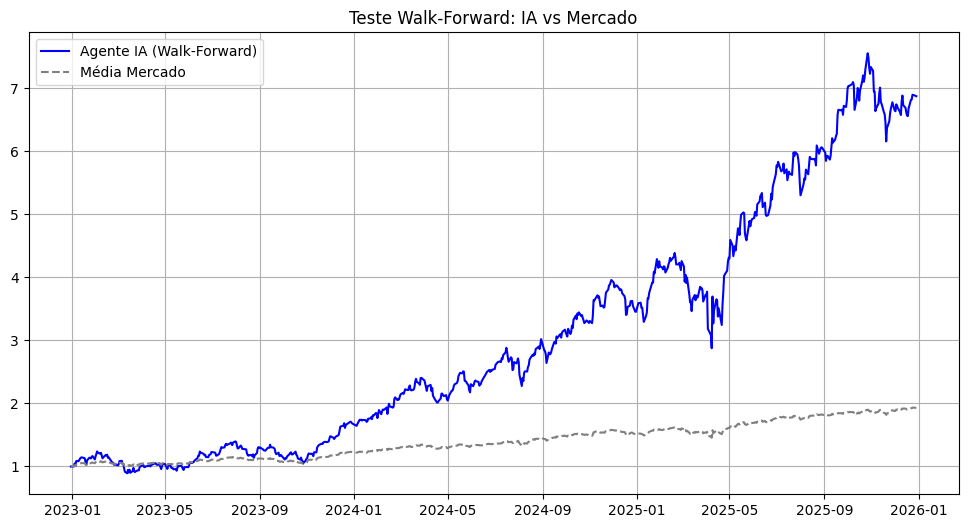

In [25]:
print("~ Calculando Performance Real ~")
# USAREMOS PARALELISMO PRA ACELERAR O CÁLCULO DA PERMUTAÇÃO
#Vamos realizar o Walk Forward e posteriormente realizar a permutação para testar a robustez do modelo
sharpe_real, dados_wf = executar_walk_forward(df_features, df_returns, verbose=True)

print(f"Sharpe Ratio Walk-Forward: {sharpe_real:.4f}")

# --- Análise e Gráficos ---
# Agora usamos 'dados_wf' que veio de dentro da função
df_wf = pd.DataFrame(dados_wf).set_index('Date')
df_wf['Cumulative_Return'] = (1 + df_wf['Return']).cumprod()

# Benchmark
market_slice = df_returns.loc[df_wf.index]
market_return = (1 + market_slice.mean(axis=1)).cumprod()

# Métricas Finais
total_ret_algo = df_wf['Cumulative_Return'].iloc[-1] - 1
total_ret_market = market_return.iloc[-1] - 1
sharpe_algo = (df_wf['Return'].mean() / df_wf['Return'].std()) * np.sqrt(252)

print("\n~ RESULTADO FINAL ~")
print(f"Retorno Acumulado IA: {total_ret_algo:.2%}")
print(f"Retorno Acumulado Mercado (Benchmark): {total_ret_market:.2%}")
print(f"Sharpe Ratio IA: {sharpe_algo:.2f}")

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_wf['Cumulative_Return'], label='Agente IA (Walk-Forward)', color='blue')
plt.plot(market_return, label='Média Mercado', color='gray', linestyle='--')
plt.title('Teste Walk-Forward: IA vs Mercado')
plt.legend()
plt.grid(True)
plt.show()

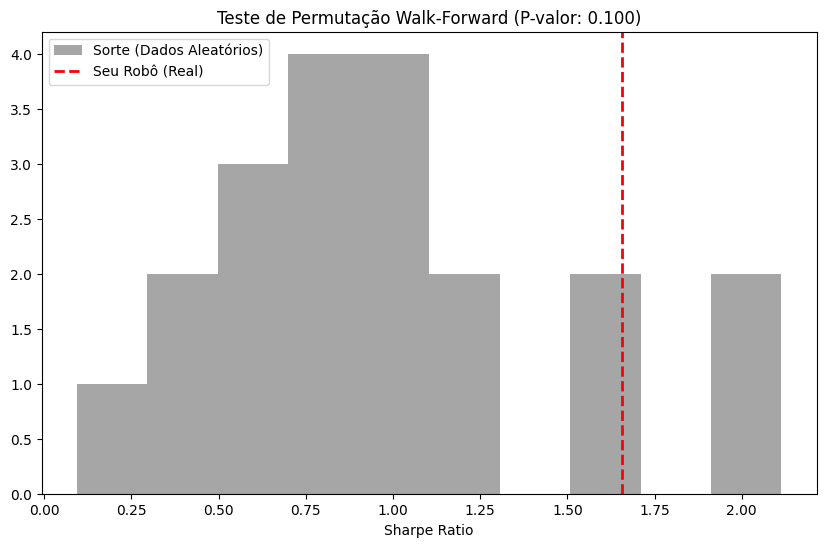

0.1


In [26]:
#PERMUTAÇÃO -------------------------------------------------------------
# Função Wrapper para o Paralelismo
def processar_permutacao(i, features, returns_original):
    torch.set_num_threads(1)
    
    returns_shuffled = returns_original.sample(frac=1, random_state=i).reset_index(drop=True)
    returns_shuffled.index = returns_original.index 
    
    # Roda o Walk-Forward 
    score, _ = executar_walk_forward(features, returns_shuffled, verbose=False)
    print(f"Permutação {i} finalizada.")
    return score

# Executa em Paralelo
sharpes_falsos = Parallel(n_jobs=-1)(
    delayed(processar_permutacao)(i, df_features, df_returns) 
    for i in range(20)
)

# Análise e Gráfico 
p_valor = np.mean(np.array(sharpes_falsos) >= sharpe_real)

plt.figure(figsize=(10, 6))
plt.hist(sharpes_falsos, bins=10, color='gray', alpha=0.7, label='Sorte (Dados Aleatórios)')
plt.axvline(sharpe_real, color='red', linestyle='--', linewidth=2, label='Seu Robô (Real)')
plt.title(f"Teste de Permutação Walk-Forward (P-valor: {p_valor:.3f})")
plt.xlabel("Sharpe Ratio")
plt.legend()
plt.show()

print(f"{p_valor}")

------------------------------
Máximo Drawdown (MDD): -34.50%
------------------------------


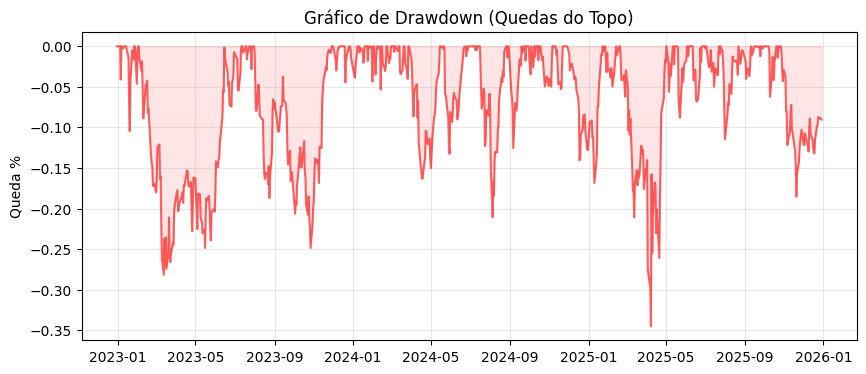

In [27]:
# --- CÁLCULO DO MÁXIMO DRAWDOWN (MDD) ---

# curva de capital acumulada
cumulative = (1 + df_wf['Return']).cumprod()

#  topo histórico a cada dia (high water mark)
peak = cumulative.cummax()

# queda percentual em relação ao topo
drawdown = (cumulative - peak) / peak

# pior queda de todas (valor mínimo)
max_drawdown = drawdown.min()

print("-" * 30)
print(f"Máximo Drawdown (MDD): {max_drawdown*100:.2f}%")
print("-" * 30)

# (gráfico de "underwater" --> mostra as quedas visualmente
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(drawdown, color='red', alpha=0.6)
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.1)
plt.title('Gráfico de Drawdown (Quedas do Topo)')
plt.ylabel('Queda %')
plt.grid(True, alpha=0.3)
plt.show()